<a href="https://colab.research.google.com/github/Raju-24-25/Deep-Learning-Handsons/blob/main/CNN_Hands_on_Using_CIFAR_10_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### `Image Classification` Using `CIFAR-10` Dataset

In [2]:
# Importing certain libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import datasets, layers, models

### Download & prepare the `CIFAR-10` dataset

*   The CIFAR10 dataset contains **60,000 color images** in `10 classes`, with `6,000 images` in each class.
*   Dataset is divided into **50,000 training images** and **10,000 testing** images.
*   Classes are mutually exclusive and there is no overlap between them
*   There is no overlap between `automobiles` and `trucks`. Truck class contains only `big` trucks

In [3]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data() #load the CIFAR-10 dataset directly from tf.keras

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step


In [5]:
train_images.shape

(50000, 32, 32, 3)

In [6]:
print("Shape of the training images:", train_images.shape)
print("Shape of the training labels:", train_labels.shape)

Shape of the training images: (50000, 32, 32, 3)
Shape of the training labels: (50000, 1)


In [7]:
print("Shape of the testing images:", test_images.shape)
print("Shape of the testing labels:", test_labels.shape)

Shape of the testing images: (10000, 32, 32, 3)
Shape of the testing labels: (10000, 1)


### Select one image randomly from the `training images set` & visualize

In [8]:
train_images

array([[[[ 59,  62,  63],
         [ 43,  46,  45],
         [ 50,  48,  43],
         ...,
         [158, 132, 108],
         [152, 125, 102],
         [148, 124, 103]],

        [[ 16,  20,  20],
         [  0,   0,   0],
         [ 18,   8,   0],
         ...,
         [123,  88,  55],
         [119,  83,  50],
         [122,  87,  57]],

        [[ 25,  24,  21],
         [ 16,   7,   0],
         [ 49,  27,   8],
         ...,
         [118,  84,  50],
         [120,  84,  50],
         [109,  73,  42]],

        ...,

        [[208, 170,  96],
         [201, 153,  34],
         [198, 161,  26],
         ...,
         [160, 133,  70],
         [ 56,  31,   7],
         [ 53,  34,  20]],

        [[180, 139,  96],
         [173, 123,  42],
         [186, 144,  30],
         ...,
         [184, 148,  94],
         [ 97,  62,  34],
         [ 83,  53,  34]],

        [[177, 144, 116],
         [168, 129,  94],
         [179, 142,  87],
         ...,
         [216, 184, 140],
        

array([[[164, 215, 244],
        [162, 212, 240],
        [162, 212, 240],
        ...,
        [157, 210, 237],
        [153, 208, 235],
        [153, 203, 234]],

       [[168, 218, 245],
        [166, 215, 242],
        [166, 215, 242],
        ...,
        [164, 212, 238],
        [160, 209, 236],
        [158, 205, 235]],

       [[172, 220, 246],
        [170, 217, 243],
        [171, 218, 244],
        ...,
        [168, 212, 238],
        [165, 208, 235],
        [163, 207, 236]],

       ...,

       [[123, 160, 105],
        [117, 154, 102],
        [112, 149,  99],
        ...,
        [117, 136, 100],
        [ 95, 115,  79],
        [120, 149, 100]],

       [[120, 156, 100],
        [116, 151,  99],
        [112, 147,  96],
        ...,
        [126, 149, 110],
        [120, 144, 103],
        [120, 152, 101]],

       [[121, 154,  96],
        [120, 152,  99],
        [116, 148,  97],
        ...,
        [124, 152, 108],
        [124, 154, 107],
        [120, 154, 100]]], dtype=uint8)
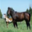

In [9]:
image = train_images[12] #13th image from 50000 images
image

In [10]:
### Extract the R,G,B channels separately
R = image[:, :, 0] #to extract one of the color channels from a color image --> RED
G = image[:, :, 1] #to extract one of the color channels from a color image --> GREEN
B = image[:, :, 2] #to extract one of the color channels from a color image --> BLUE

### Display the original image along with `RGB` channels

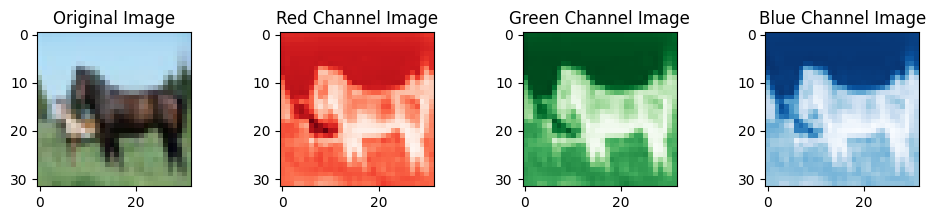

In [11]:
fig, axs = plt.subplots(nrows=1, ncols=4,figsize=(12,2))

# Original Image
axs[0].imshow(image)
axs[0].set_title("Original Image")

# Red Channel Image
axs[1].imshow(R, cmap = 'Reds')
axs[1].set_title("Red Channel Image")

# Green Channel Image
axs[2].imshow(G, cmap = 'Greens')
axs[2].set_title("Green Channel Image")

# Blue Channel Image
axs[3].imshow(B, cmap = 'Blues')
axs[3].set_title("Blue Channel Image")

plt.show()

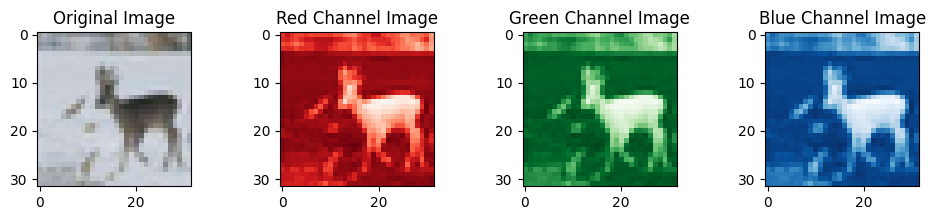

In [14]:
image = train_images[20]
# Extract the R,G,B channels separately
R = image[:, :, 0] #to extract one of the color channels from a color image --> RED
G = image[:, :, 1] #to extract one of the color channels from a color image --> GREEN
B = image[:, :, 2] #to extract one of the color channels from a color image --> BLUE


# Setting up the canvas
fig, axs = plt.subplots(nrows=1, ncols=4,figsize=(12,2))

# Original Image
axs[0].imshow(image)
axs[0].set_title("Original Image")

# Red Channel Image
axs[1].imshow(R, cmap = 'Reds')
axs[1].set_title("Red Channel Image")

# Green Channel Image
axs[2].imshow(G, cmap = 'Greens')
axs[2].set_title("Green Channel Image")

# Blue Channel Image
axs[3].imshow(B, cmap = 'Blues')
axs[3].set_title("Blue Channel Image")

plt.show()

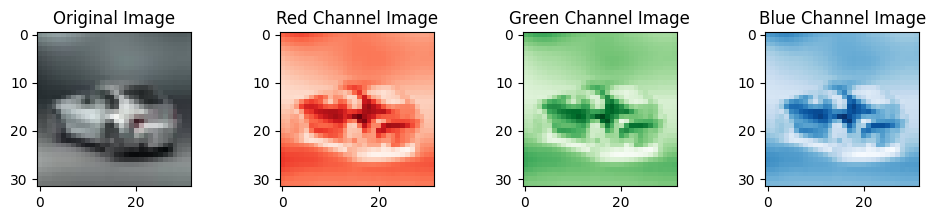

In [15]:
image = train_images[250]
# Extract the R,G,B channels separately
R = image[:, :, 0] #to extract one of the color channels from a color image --> RED
G = image[:, :, 1] #to extract one of the color channels from a color image --> GREEN
B = image[:, :, 2] #to extract one of the color channels from a color image --> BLUE


# Setting up the canvas
fig, axs = plt.subplots(nrows=1, ncols=4,figsize=(12,2))

# Original Image
axs[0].imshow(image)
axs[0].set_title("Original Image")

# Red Channel Image
axs[1].imshow(R, cmap = 'Reds')
axs[1].set_title("Red Channel Image")

# Green Channel Image
axs[2].imshow(G, cmap = 'Greens')
axs[2].set_title("Green Channel Image")

# Blue Channel Image
axs[3].imshow(B, cmap = 'Blues')
axs[3].set_title("Blue Channel Image")

plt.show()

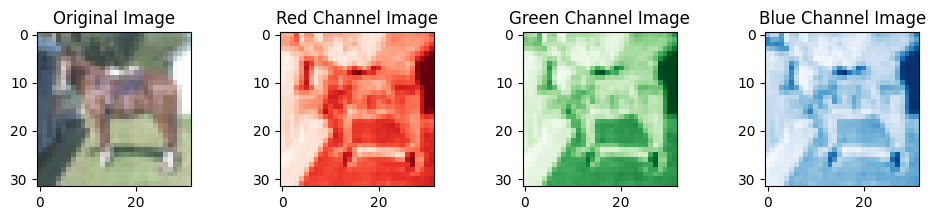

In [16]:
image = train_images[2366]
# Extract the R,G,B channels separately
R = image[:, :, 0] #to extract one of the color channels from a color image --> RED
G = image[:, :, 1] #to extract one of the color channels from a color image --> GREEN
B = image[:, :, 2] #to extract one of the color channels from a color image --> BLUE


# Setting up the canvas
fig, axs = plt.subplots(nrows=1, ncols=4,figsize=(12,2))

# Original Image
axs[0].imshow(image)
axs[0].set_title("Original Image")

# Red Channel Image
axs[1].imshow(R, cmap = 'Reds')
axs[1].set_title("Red Channel Image")

# Green Channel Image
axs[2].imshow(G, cmap = 'Greens')
axs[2].set_title("Green Channel Image")

# Blue Channel Image
axs[3].imshow(B, cmap = 'Blues')
axs[3].set_title("Blue Channel Image")

plt.show()

### Let us plot a `few more` but this time with class/label as legend

In [17]:
np.unique(train_labels)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [18]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

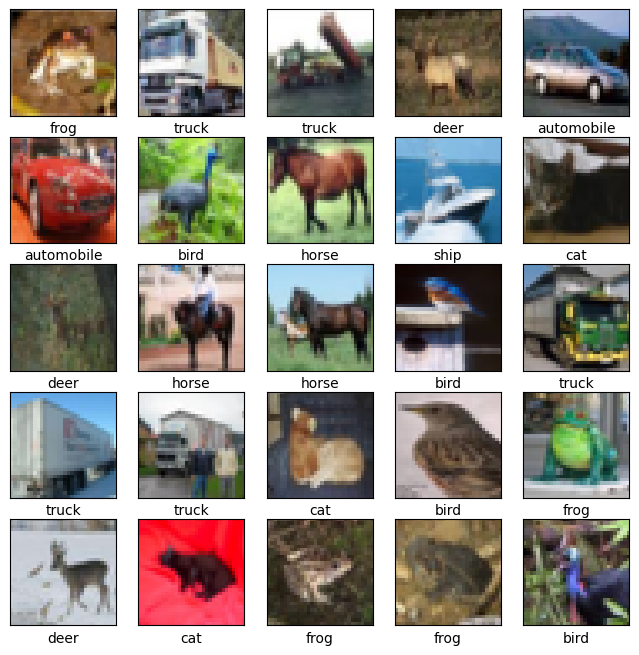

In [19]:
plt.figure(figsize = (8,8))

for i in range(25):
  plt.subplot(5, 5, i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)

  plt.imshow(train_images[i]) #plot the images from traiining set from 0 to 24 indices
  plt.xlabel(class_names[train_labels[i][0]]) #tag the class label to the respective class names using my class_names list

###  PLOTTING RANDOM 30-40 IMAGES WITH LABELS

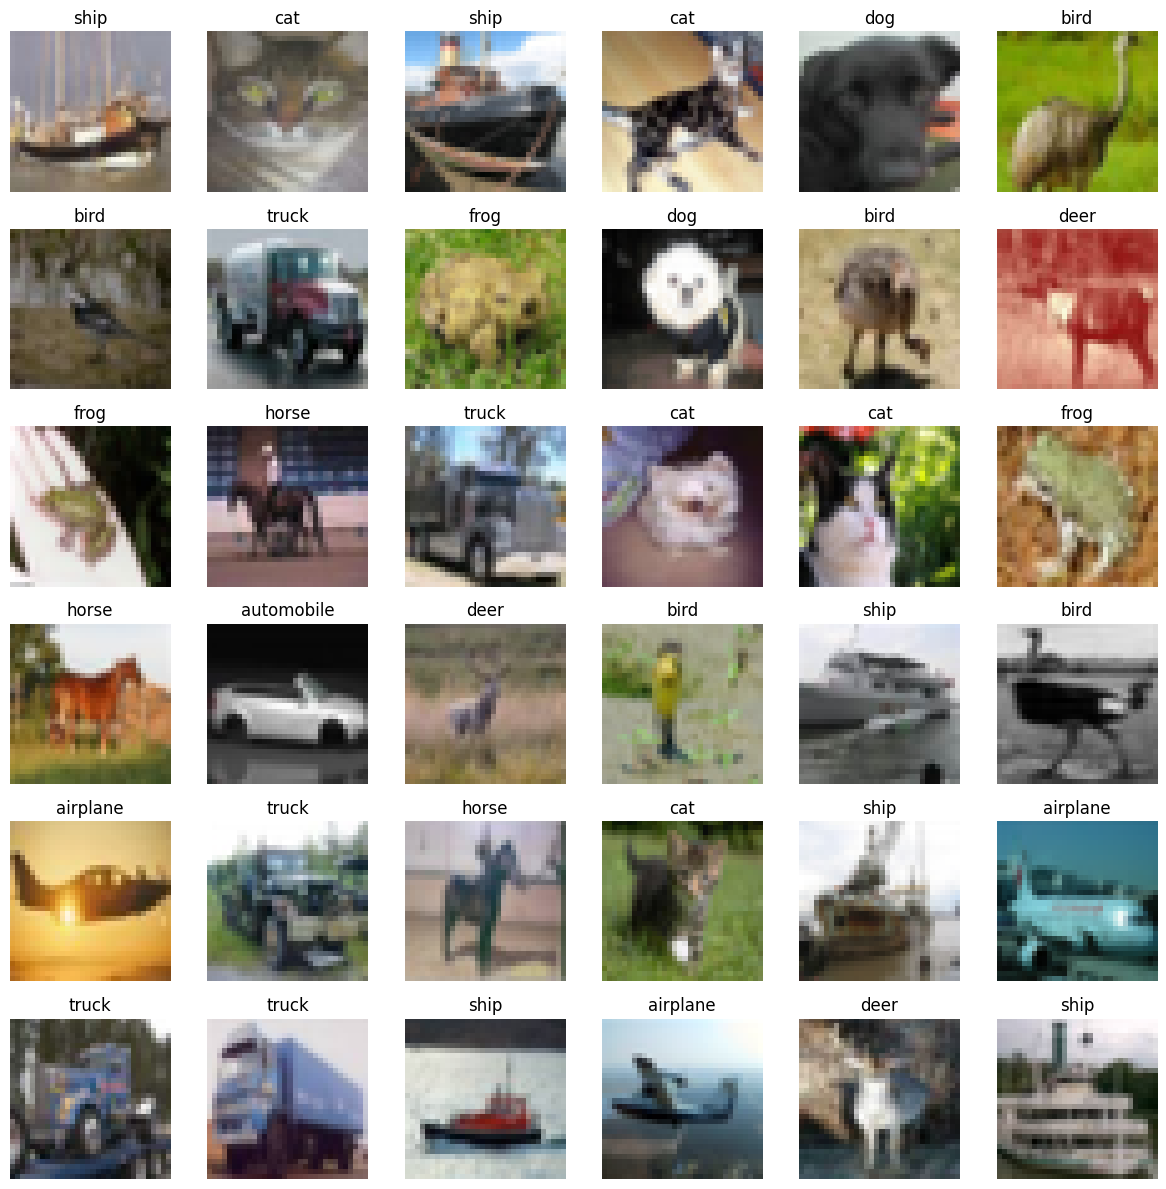

In [20]:
import random
import matplotlib.pyplot as plt
import numpy as np

# CIFAR-10 class labels
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# Number of images to display
num_images = 36   # you can change to 30–40

# Generate random indices
indices = np.random.permutation(len(train_images))[:num_images]

# Plot images
plt.figure(figsize=(12, 12))

for i, idx in enumerate(indices):
    plt.subplot(6, 6, i+1)   # 6x6 grid for 36 images
    plt.imshow(train_images[idx])
    plt.title(class_names[train_labels[idx][0]])
    plt.axis('off')

plt.tight_layout()
plt.show()

### Understanding the `CONVOLUTION OPERATION`

In [21]:
from PIL import Image, ImageChops
import requests
from PIL import Image
from io import BytesIO

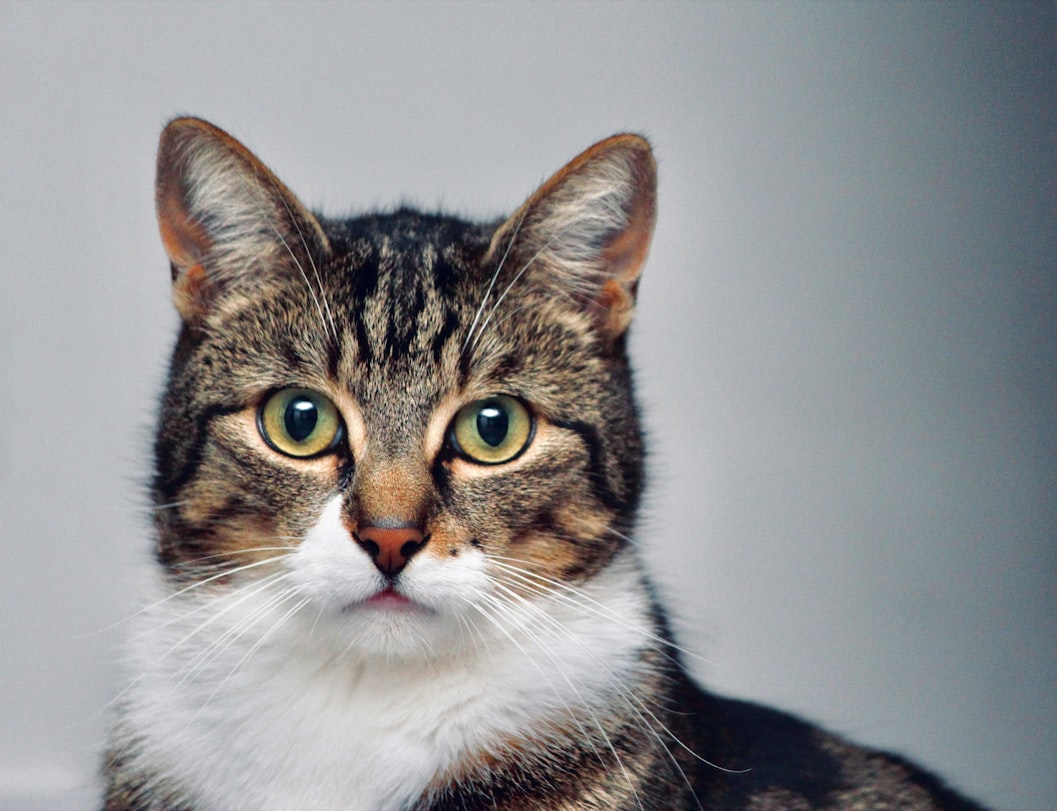

In [23]:
image_url = 'https://images.unsplash.com/photo-1583795128727-6ec3642408f8?q=80&w=1057&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D'
response = requests.get(image_url)
img = Image.open(BytesIO(response.content))
display(img)



In [24]:
# To get the size of the CAT's image
width, height = img.size
print("Width of the CAT's image:", width, "px")
print("Height of the CAT's image:", height, "px")

Width of the CAT's image: 1057 px
Height of the CAT's image: 811 px


In [25]:
# Let us resize image from its original size to 200 by 200 pixels
img_resized = img.resize((200, 200))
width1, height1 = img_resized.size
print("Width of the resized CAT's image:", width1, "px")
print("Height of the resized CAT's image:", height1, "px")

Width of the resized CAT's image: 200 px
Height of the resized CAT's image: 200 px


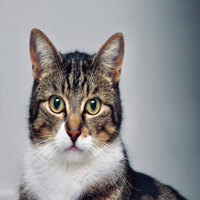

In [26]:
display(img_resized)

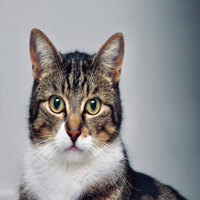

In [27]:
img_resized

### Convert the `resized image` into an array

array([[[183, 183, 188],
        [182, 183, 188],
        [184, 184, 190],
        ...,
        [ 66,  79,  93],
        [ 65,  76,  88],
        [ 66,  80,  92]],

       [[183, 184, 188],
        [180, 184, 188],
        [183, 185, 190],
        ...,
        [ 67,  78,  92],
        [ 67,  75,  88],
        [ 66,  78,  93]],

       [[183, 184, 188],
        [181, 184, 189],
        [182, 185, 190],
        ...,
        [ 70,  81,  93],
        [ 69,  76,  90],
        [ 66,  77,  94]],

       ...,

       [[179, 179, 185],
        [175, 178, 184],
        [176, 180, 186],
        ...,
        [108, 120, 129],
        [101, 118, 125],
        [100, 118, 125]],

       [[175, 177, 183],
        [173, 177, 184],
        [176, 178, 185],
        ...,
        [108, 119, 129],
        [104, 120, 126],
        [100, 118, 124]],

       [[173, 176, 183],
        [171, 174, 183],
        [175, 175, 183],
        ...,
        [111, 117, 130],
        [105, 117, 126],
        [102, 115, 125]]], dtype=uint8)
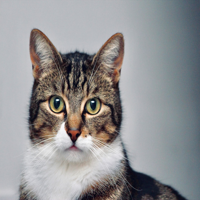

In [28]:
cat_img_array = np.array(img_resized)
cat_img_array

### Convert original `CAT` image to `grayscale` image

In [29]:
pip install opencv-python

In [30]:
import cv2
print(cv2.__version__)

4.13.0


array([[184, 183, 185, ...,  77,  74,  77],
       [184, 183, 185, ...,  76,  74,  76],
       [184, 184, 185, ...,  79,  76,  76],
       ...,
       [180, 178, 179, ..., 117, 114, 113],
       [177, 177, 178, ..., 117, 116, 113],
       [176, 174, 176, ..., 117, 114, 112]], dtype=uint8)
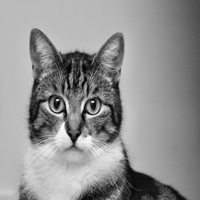

In [31]:
gray_cat = cv2.cvtColor(cat_img_array, cv2.COLOR_RGB2GRAY)
display(gray_cat)

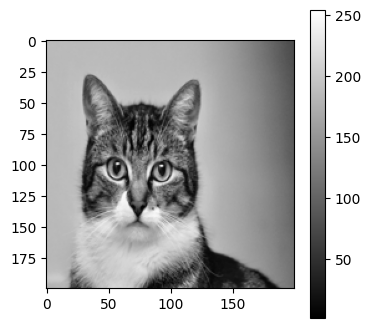

In [32]:
# let us plot the grayscale cat's image
plt.figure(figsize=(4,4))
plt.imshow(gray_cat, cmap = 'gray')
plt.colorbar()
plt.show()

In [33]:
img_resized_tiny = np.array(img.resize((64, 64)))

In [34]:
img_resized_tiny_gray  = cv2.cvtColor(img_resized_tiny, cv2.COLOR_RGB2GRAY)

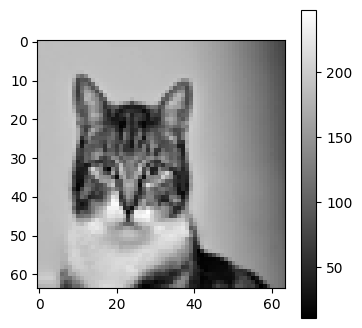

In [35]:
# Let us plot the grayscale CAT
plt.figure(figsize=(4,4))
plt.imshow(img_resized_tiny_gray, cmap='gray')
plt.colorbar()
plt.show()

array([[184, 183, 185, ...,  77,  74,  77],
       [184, 183, 185, ...,  76,  74,  76],
       [184, 184, 185, ...,  79,  76,  76],
       ...,
       [180, 178, 179, ..., 117, 114, 113],
       [177, 177, 178, ..., 117, 116, 113],
       [176, 174, 176, ..., 117, 114, 112]], dtype=uint8)
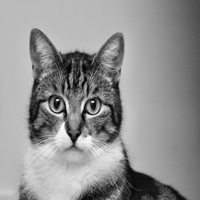

In [36]:
gray_cat

In [37]:
filters = {
     'Original': gray_cat,
    'Sobel X': cv2.Sobel(gray_cat, cv2.CV_64F, 1, 0, ksize = 3),
    'Sobel Y': cv2.Sobel(gray_cat, cv2.CV_64F, 0, 1, ksize = 3),
    'Laplacian': cv2.Laplacian(gray_cat, cv2.CV_64F),
    'Sharpen': cv2.filter2D(gray_cat, -1, kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])),
    'Gaussian Blur': cv2.GaussianBlur(gray_cat, (5,5), 0)
}

### Plot the results of the above filters

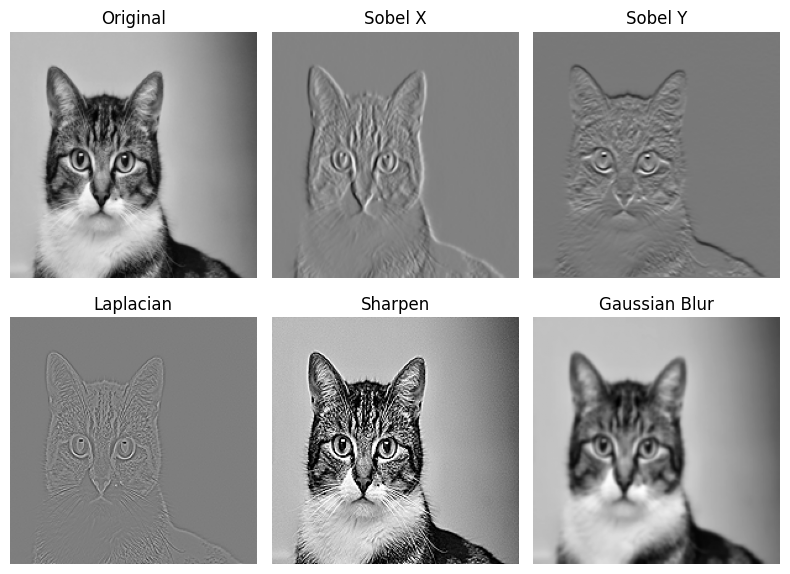

In [38]:
plt.figure(figsize = (8,6))

for i, (title, img) in enumerate(filters.items(),1):
    plt.subplot(2,3,i)
    cmap = 'gray' if len(img.shape)==2 else None
    plt.imshow(img, cmap = cmap)
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.show()

### Let us create `base` convolutional neural network model

In [39]:
base_model = models.Sequential()

In [40]:
base_model

<Sequential name=sequential, built=False>

In [41]:
### Adding the first convolutional layer (filter layer on top of the input images) followed by max pooling
base_model.add(layers.Conv2D(32, (3,3), activation = 'relu', input_shape = (32, 32, 3))) #adding a conv2D layer having 32 filters with kernel/filter size: 3X3
base_model.add(layers.MaxPool2D((2,2))) #adds a maximum pooling layer of size: 2X2 --> to reduce the spatial dimensions --> by half in both row and column

### Adding the second convolutional layer (filter layer on top of the input images) followed by max pooling
base_model.add(layers.Conv2D(64, (3,3), activation = 'relu')) #adding a second conv2D layer having 64 filters with kernel/filter size: 3X3 on top of the first convolution + pooling layer
base_model.add(layers.MaxPool2D((2,2))) #adds another maximum pooling layer of size: 2X2 --> to reduce the spatial dimensions --> by half in both row and column

### Adding the third convolutional layer
base_model.add(layers.Conv2D(64, (3,3), activation = 'relu')) #adding a third conv2D layer having 64 filters with kernel/filter size: 3X3 on top of the first convolution + pooling layer

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:
base_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,320 (220.00 KB)

 Trainable params: 56,320 (220.00 KB)

 Non-trainable params: 0 (0.00 B)

### Let us add `ANN` block on top of the above `CNN` block

In [43]:
base_model.add(layers.Flatten()) #converts a multi-dimensional input coming from CNN into a 1-D vector
base_model.add(layers.Dense(64, activation = 'relu')) # a dense layer which means fully connected layer having 64 neurons with `RelU` as activation function
base_model.add(layers.Dense(10)) #final layer is the output layer with 10 neurons for 10 classes/categories

In [44]:
base_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

### Compile & train the model

In [45]:
base_model.compile(optimizer='adam',
                   loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                   metrics = ['accuracy']
                  )

In [46]:
history_01 = base_model.fit(train_images, train_labels, epochs = 50, validation_data=(test_images, test_labels))

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 48ms/step - accuracy: 0.3812 - loss: 1.7627 - val_accuracy: 0.4851 - val_loss: 1.4155
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 74s 47ms/step - accuracy: 0.5359 - loss: 1.3153 - val_accuracy: 0.5600 - val_loss: 1.2487
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 46ms/step - accuracy: 0.5862 - loss: 1.1763 - val_accuracy: 0.5798 - val_loss: 1.1857
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 47ms/step - accuracy: 0.6205 - loss: 1.0816 - val_accuracy: 0.6037 - val_loss: 1.1340
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 44ms/step - accuracy: 0.6508 - loss: 0.9976 - val_accuracy: 0.6241 - val_loss: 1.0866
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 43ms/step - accuracy: 0.6750 - loss: 0.9304 - val_accuracy: 0.6169 - val_loss: 1.1117
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 44ms/step - accuracy: 0.6947 - loss: 0.8722 - val_accuracy: 0.6521 - val_loss: 1.0465
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 44ms/step - accuracy: 0.7157 -

### Plotting the `accuracy vs epoch` chart for `training` and `validation` set

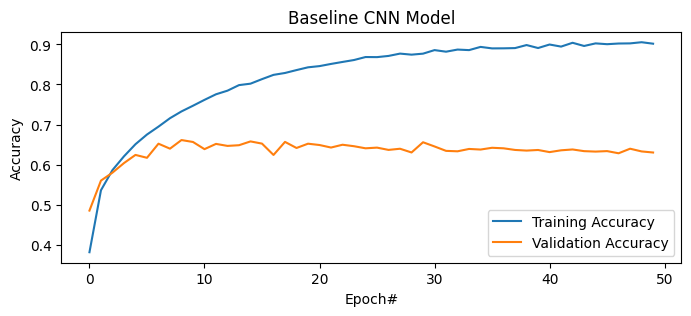

In [47]:
plt.figure(figsize = (8,3))

plt.plot(history_01.history['accuracy'], label = 'Training Accuracy')
plt.plot(history_01.history['val_accuracy'], label = 'Validation Accuracy')
plt.xlabel('Epoch#')
plt.ylabel('Accuracy')
plt.title('Baseline CNN Model')
plt.legend()
plt.show()

#### Capturing the performance of the `base` CNN model
- epochs: `50`
- training accuracy: `90%`
- validation accuracy: `63%`

##### model is highly `overfit` and needs to be fixed

### `Fine-tuning` the `base` CNN model

#### Technique #1: `BATCH NORMALIZATION`

- is a technique that normalizes the activations inside a neural network layer so training model becomes less sensitive to initialization and avoid likely scenarios of `exploding` or `vanishing` gradients

In [48]:
bn_model = models.Sequential() #placeholder for the batch normalized model

In [49]:
### Adding the first convolutional layer (filter layer on top of the input images) followed by max pooling
bn_model.add(layers.Conv2D(32, (3,3), activation = 'relu', input_shape = (32, 32, 3))) #adding a conv2D layer having 32 filters with kernel/filter size: 3X3

### Adding a batch normalization layer after the first convolution layer
bn_model.add(layers.BatchNormalization()) #normalized the output of the convolution layer

### Max Pooling layer
bn_model.add(layers.MaxPool2D((2,2))) #adds a maximum pooling layer of size: 2X2 --> to reduce the spatial dimensions --> by half in both row and column

### Adding the second convolutional layer (filter layer on top of the input images) followed by max pooling
bn_model.add(layers.Conv2D(64, (3,3), activation = 'relu')) #adding a second conv2D layer having 64 filters with kernel/filter size: 3X3 on top of the first convolution + pooling layer

### Adding another batch normalization layer after the second convolution layer
bn_model.add(layers.BatchNormalization()) #normalized the output of the convolution layer

### Max Pooling layer
bn_model.add(layers.MaxPool2D((2,2))) #adds another maximum pooling layer of size: 2X2 --> to reduce the spatial dimensions --> by half in both row and column

### Adding the third convolutional layer
bn_model.add(layers.Conv2D(64, (3,3), activation = 'relu')) #adding a third conv2D layer having 64 filters with kernel/filter size: 3X3 on top of the first convolution + pooling layer

In [50]:
bn_model.add(layers.Flatten()) #converts a multi-dimensional input coming from CNN into a 1-D vector
bn_model.add(layers.Dense(64, activation = 'relu')) # a dense layer which means fully connected layer having 64 neurons with `RelU` as activation function
bn_model.add(layers.Dense(10)) #final layer is the output layer with 10 neurons for 10 classes/categories

In [51]:
bn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,954 (480.29 KB)

 Trainable params: 122,762 (479.54 KB)

 Non-trainable params: 192 (768.00 B)

In [52]:
bn_model.compile(optimizer='adam',
                   loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                   metrics = ['accuracy']
                  )

In [53]:
history_02 = bn_model.fit(train_images, train_labels, epochs = 50, validation_data=(test_images, test_labels))

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 100s 62ms/step - accuracy: 0.5172 - loss: 1.3467 - val_accuracy: 0.5238 - val_loss: 1.3643
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 97s 62ms/step - accuracy: 0.6522 - loss: 0.9887 - val_accuracy: 0.6454 - val_loss: 1.0347
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 97s 62ms/step - accuracy: 0.7050 - loss: 0.8422 - val_accuracy: 0.5481 - val_loss: 1.5062
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 141s 61ms/step - accuracy: 0.7408 - loss: 0.7455 - val_accuracy: 0.6345 - val_loss: 1.0658
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 144s 63ms/step - accuracy: 0.7633 - loss: 0.6717 - val_accuracy: 0.6620 - val_loss: 1.0424
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 97s 62ms/step - accuracy: 0.7868 - loss: 0.6053 - val_accuracy: 0.6816 - val_loss: 0.9654
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 141s 61ms/step - accuracy: 0.8075 - loss: 0.5482 - val_accuracy: 0.6909 - val_loss: 0.9838
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 96s 62ms/step - accuracy: 0.82

### Plotting the `accuracy vs epoch` chart for `training` and `validation` set

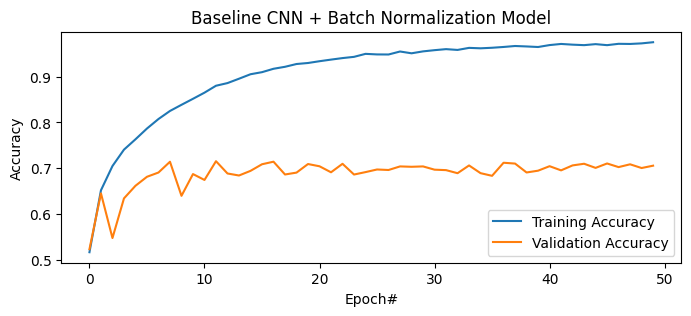

In [54]:
plt.figure(figsize = (8,3))

plt.plot(history_02.history['accuracy'], label = 'Training Accuracy')
plt.plot(history_02.history['val_accuracy'], label = 'Validation Accuracy')
plt.xlabel('Epoch#')
plt.ylabel('Accuracy')
plt.title('Baseline CNN + Batch Normalization Model')
plt.legend()
plt.show()

#### Capturing the performance of the `base + batch normalization` CNN model
- epochs: `50`
- training accuracy: `97.5%`
- validation accuracy: `70.5%`

##### model is still `overfit` however training accuracy has significantly improved

### Fine-tuning the base model with `Batch Normalization` + `DropOut` + `L2 Regularization`

In [55]:
bn_dropout_l2_model = models.Sequential() #placeholder model

In [56]:
from tensorflow.keras.regularizers import l2

In [57]:
## Adding the first convolutional layer (filter layer on top of the input images) followed by max pooling
bn_dropout_l2_model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape = (32, 32, 3))) #added a conv2D layer having 32 filters with kernel_size: 3 X3

### Adding a batch normalization after the first convolution layer
bn_dropout_l2_model.add(layers.BatchNormalization()) # normalizes the ouput of the convolution layer

### First pooling layer
bn_dropout_l2_model.add(layers.MaxPool2D((2, 2))) #adds a max pooling layer with pool size of 2X2 --> to reduce the spatial dimensions --> by half

### Dropout Layer
bn_dropout_l2_model.add(layers.Dropout(0.25)) #dropping out 25% of the neurons


## Adding the second convolutional layer followed by max pooling
bn_dropout_l2_model.add(layers.Conv2D(64, (3,3), activation='relu', kernel_regularizer=l2(0.01))) #added a conv2D layer having 64 filters with kernel_size: 3 X3

### Adding a batch normalization after the second convolution layer
bn_dropout_l2_model.add(layers.BatchNormalization()) # normalizes the ouput of the convolution layer

### Second Pooling Layer
bn_dropout_l2_model.add(layers.MaxPool2D((2, 2))) #adds a max pooling layer with pool size of 2X2 --> to reduce the spatial dimensions --> by half

### Dropout Layer
bn_dropout_l2_model.add(layers.Dropout(0.25)) #dropping out 25% of the neurons

## Adding the third convolutional layer but no max pooling
bn_dropout_l2_model.add(layers.Conv2D(64, (3,3), activation='relu', kernel_regularizer=l2(0.01))) #added a conv2D layer having 64 filters with kernel_size: 3 X3

## Let us add `ANN` block on top of the above `CNN` block

In [58]:
bn_dropout_l2_model.add(layers.Flatten()) # converts a multi-dimensional input coming from CNN into a 1D vector
bn_dropout_l2_model.add(layers.Dense(64, activation='relu')) #a dense layer which means fully connected layer having 64 neurons with af as 'ReLU'
bn_dropout_l2_model.add(layers.Dense(10)) #final layer which is output layer with 10 neurons given that there are 10 classes in CIFAR-10 dataset

In [59]:
bn_dropout_l2_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,954 (480.29 KB)

 Trainable params: 122,762 (479.54 KB)

 Non-trainable params: 192 (768.00 B)

### Compile and train the model

In [60]:
bn_dropout_l2_model.compile(optimizer = 'adam',
                   loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                metrics = ['accuracy'])

In [61]:
history_03 = bn_dropout_l2_model.fit(train_images, train_labels, epochs = 50, validation_data=(test_images, test_labels))

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 107s 67ms/step - accuracy: 0.4766 - loss: 1.8607 - val_accuracy: 0.5162 - val_loss: 1.5859
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 103s 66ms/step - accuracy: 0.6024 - loss: 1.3338 - val_accuracy: 0.6072 - val_loss: 1.3394
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 142s 66ms/step - accuracy: 0.6406 - loss: 1.2442 - val_accuracy: 0.6384 - val_loss: 1.2549
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 106s 68ms/step - accuracy: 0.6556 - loss: 1.1994 - val_accuracy: 0.6301 - val_loss: 1.2743
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 109s 70ms/step - accuracy: 0.6693 - loss: 1.1652 - val_accuracy: 0.6891 - val_loss: 1.1087
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 103s 66ms/step - accuracy: 0.6784 - loss: 1.1383 - val_accuracy: 0.6432 - val_loss: 1.2436
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 109s 70ms/step - accuracy: 0.6873 - loss: 1.1142 - val_accuracy: 0.6851 - val_loss: 1.1238
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 103s 66ms/step - accuracy: 

### Plotting the `accuracy vs epoch` chart for `training` and `validation` set

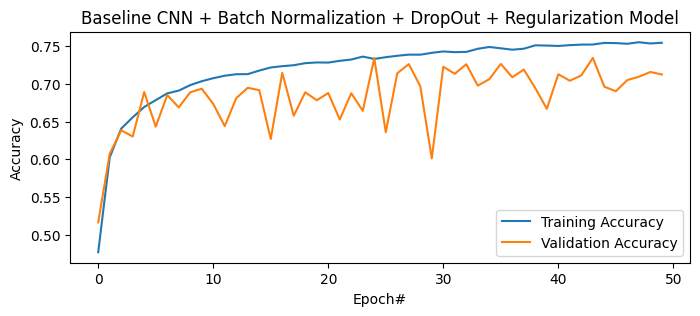

In [62]:
plt.figure(figsize = (8,3))

plt.plot(history_03.history['accuracy'], label = 'Training Accuracy')
plt.plot(history_03.history['val_accuracy'], label = 'Validation Accuracy')
plt.xlabel('Epoch#')
plt.ylabel('Accuracy')
plt.title('Baseline CNN + Batch Normalization + DropOut + Regularization Model')
plt.legend()
plt.show()

#### Capturing the performance of the `base + Batch Normalization + DropOut + Regularization` CNN model
- epochs: `50`
- training accuracy: `75%`
- validation accuracy: `71%`

##### model is not `overfit` however overall training & validation can be improved